# Проект: классификация

In [262]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import warnings

warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder
from sklearn import linear_model
from sklearn import tree
from sklearn import ensemble
from sklearn import metrics
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif

## Часть 1. Знакомство с данными, обработка пропусков и выбросов

### Задание 1

In [182]:
df = pd.read_csv('bank_fin.csv', sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,"2 343,00 $",yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,"45,00 $",no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,"1 270,00 $",yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,"2 476,00 $",yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,"184,00 $",no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [183]:
df.isna().sum()

age           0
job           0
marital       0
education     0
default       0
balance      25
housing       0
loan          0
contact       0
day           0
month         0
duration      0
campaign      0
pdays         0
previous      0
poutcome      0
deposit       0
dtype: int64

### Задание 2

In [184]:
df['job'].unique()

array(['admin.', 'technician', 'services', 'management', 'retired',
       'blue-collar', 'unemployed', 'entrepreneur', 'housemaid',
       'unknown', 'self-employed', 'student'], dtype=object)

### Задание 3

In [185]:
df['balance'] = df['balance'].str.replace(r'[ \$]', '', regex=True)
df['balance'] = df['balance'].str.replace(',', '.')
df['balance'] = df['balance'].astype(float)
df['balance'].head()

0    2343.0
1      45.0
2    1270.0
3    2476.0
4     184.0
Name: balance, dtype: float64

In [186]:
df['balance'].mean()

1529.1290293615875

### Задание 4

In [187]:
df['balance'] = df['balance'].fillna(df['balance'].median())
df['balance'].mean()

1526.9360329690019

### Задание 5

In [188]:
# обработайте пропуски в категориальных признаках: job и education, заменив их на модальные значения
most_common_job = df['job'].mode().iloc[0]
most_common_education = df['education'].mode().iloc[0]

df['job'] = df['job'].str.replace('unknown', most_common_job)
df['education'] = df['education'].str.replace('unknown', most_common_education)

In [189]:
df[
    (df['job'] == df['job'].mode().iloc[0]) &
    (df['education'] == df['education'].mode().iloc[0])
    ]['balance'].mean()

1598.8829787234042

### Задание 6

In [190]:
# удалите все выбросы для признака balance
q_1 = np.percentile(df['balance'], 25)
q_3 = np.percentile(df['balance'], 75)
iqr = q_3 - q_1

lower_bound = q_1 - 1.5 * iqr
upper_bound = q_3 + 1.5 * iqr

print(lower_bound, upper_bound)

-2241.0 4063.0


In [191]:
df = df[(df['balance'] >= lower_bound) & (df['balance'] <= upper_bound)]

In [192]:
df.shape

(10105, 17)

## Часть 2:  Разведывательный анализ

### Задание 1

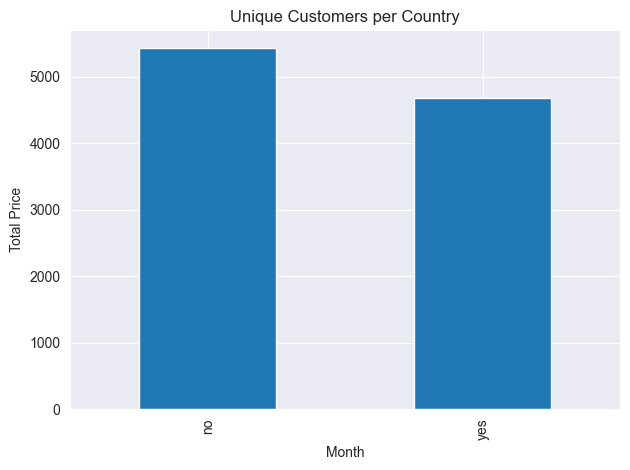

In [193]:
# Строим график
plt.figure()
df['deposit'].value_counts().plot(kind='bar')
plt.xlabel('Month')
plt.ylabel('Total Price')
plt.title('Unique Customers per Country')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [194]:
df['deposit'].value_counts()

deposit
no     5424
yes    4681
Name: count, dtype: int64

### Задания 2 и 3

In [195]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,10105.000000,10105.000000,10105.000000,10105.000000,10105.000000,10105.000000,10105.000000
mean,40.895497,807.653538,15.590302,368.742603,2.517170,51.319644,0.816230
std,11.734931,994.151966,8.441510,346.651524,2.707159,109.644179,2.243795
min,18.000000,-2049.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,95.000000,8.000000,137.000000,1.000000,-1.000000,0.000000
50%,38.000000,445.000000,15.000000,252.000000,2.000000,-1.000000,0.000000
75%,48.000000,1227.000000,22.000000,490.000000,3.000000,2.000000,1.000000
max,95.000000,4063.000000,31.000000,3881.000000,43.000000,854.000000,58.000000


### Задания 4 и 5

In [227]:
df.describe(include='object')

ValueError: No objects to concatenate

### Задание 6

In [197]:
df['poutcome'].value_counts()

poutcome
unknown    7570
failure    1109
success     945
other       481
Name: count, dtype: int64

### Задание 7

In [198]:
df.groupby('month')['deposit'] \
    .apply(lambda x: (x == 'no').mean() * 100) \
    .reset_index()

,month,deposit
0,apr,38.192771
1,aug,55.956679
2,dec,9.677419
3,feb,45.557123
4,jan,60.815047
5,jul,58.956276
6,jun,54.891304
7,mar,10.126582
8,may,67.863966
9,nov,58.461538


### Задание 8

In [199]:
# задаём границы бинов и подписи для них
bins = [0, 30, 40, 50, 60, float('inf')]
labels = ['<30', '30–40', '40–50', '50–60', '60+']

# создаём новый столбец с категориями
df['age_group'] = pd.cut(
    df['age'],
    bins=bins,
    labels=labels,
    right=False,  # интервал включается слева, исключается справа: [)
    include_lowest=True  # чтобы самое маленькое значение попало в первый бин
)

In [200]:
df.groupby('age_group')['deposit'] \
    .apply(lambda x: (x == 'yes').mean() * 100) \
    .reset_index()

,age_group,deposit
0,<30,59.175258
1,30–40,43.322393
2,40–50,39.378673
3,50–60,40.507860
4,60+,75.957121


### Задания 9 и 10

<Figure size 640x480 with 0 Axes>

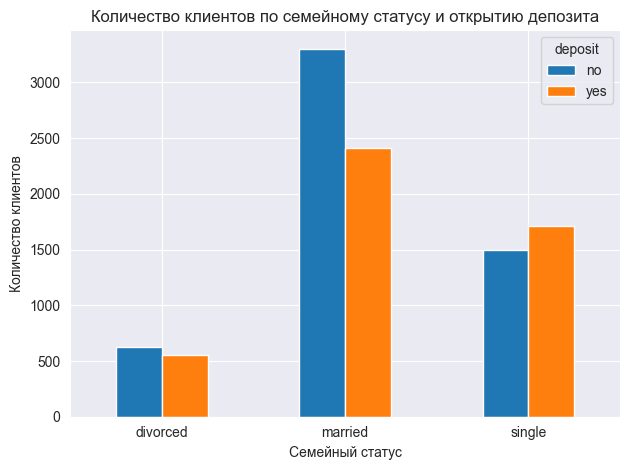

In [201]:
pivot_counts = (
    df
    .groupby(['marital', 'deposit'])
    .size()
    .unstack(fill_value=0)
)

# 1) Группированный столбчатый график по абсолютным количествам
plt.figure()
pivot_counts.plot(kind='bar')
plt.title('Количество клиентов по семейному статусу и открытию депозита')
plt.xlabel('Семейный статус')
plt.ylabel('Количество клиентов')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

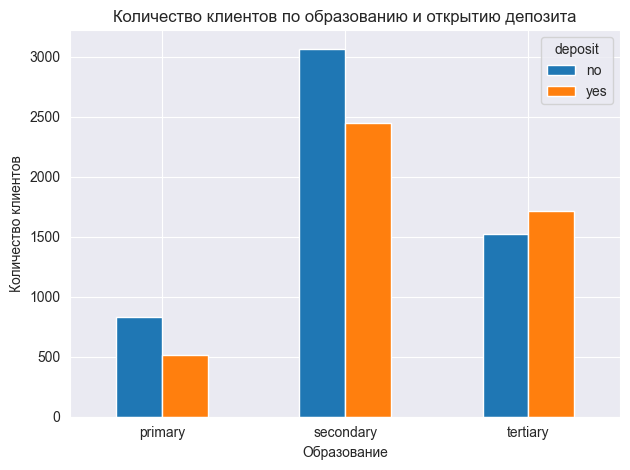

In [202]:
pivot_counts = (
    df
    .groupby(['education', 'deposit'])
    .size()
    .unstack(fill_value=0)
)

# 1) Группированный столбчатый график по абсолютным количествам
plt.figure()
pivot_counts.plot(kind='bar')
plt.title('Количество клиентов по образованию и открытию депозита')
plt.xlabel('Образование')
plt.ylabel('Количество клиентов')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

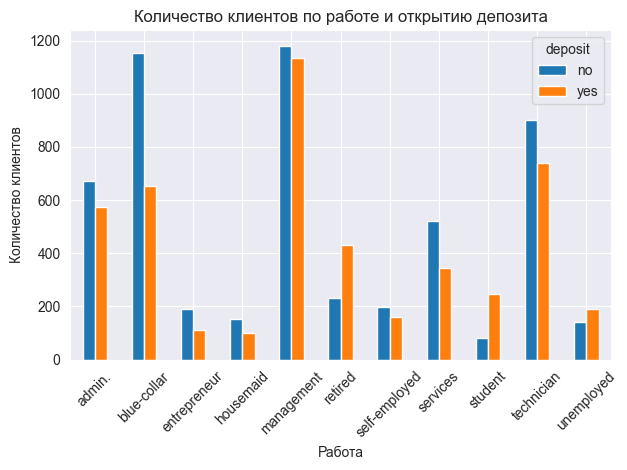

In [203]:
pivot_counts = (
    df
    .groupby(['job', 'deposit'])
    .size()
    .unstack(fill_value=0)
)

# 1) Группированный столбчатый график по абсолютным количествам
plt.figure()
pivot_counts.plot(kind='bar')
plt.title('Количество клиентов по работе и открытию депозита')
plt.xlabel('Работа')
plt.ylabel('Количество клиентов')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Задание 11

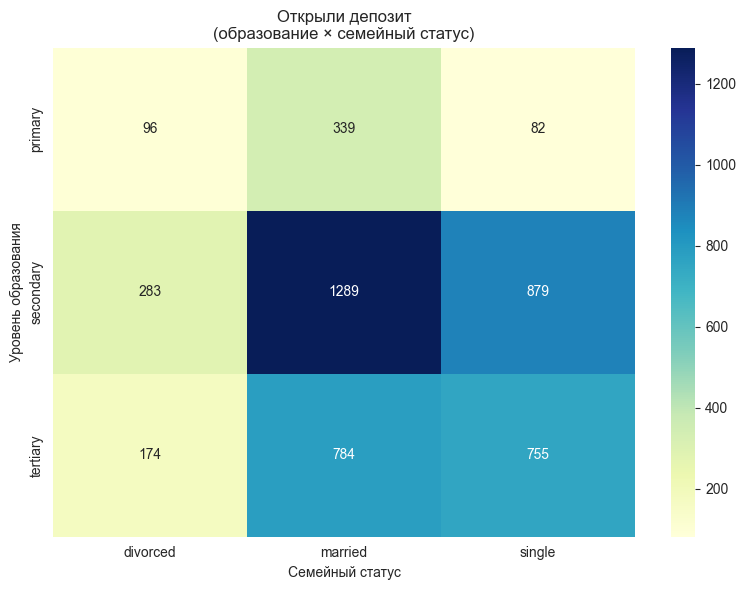

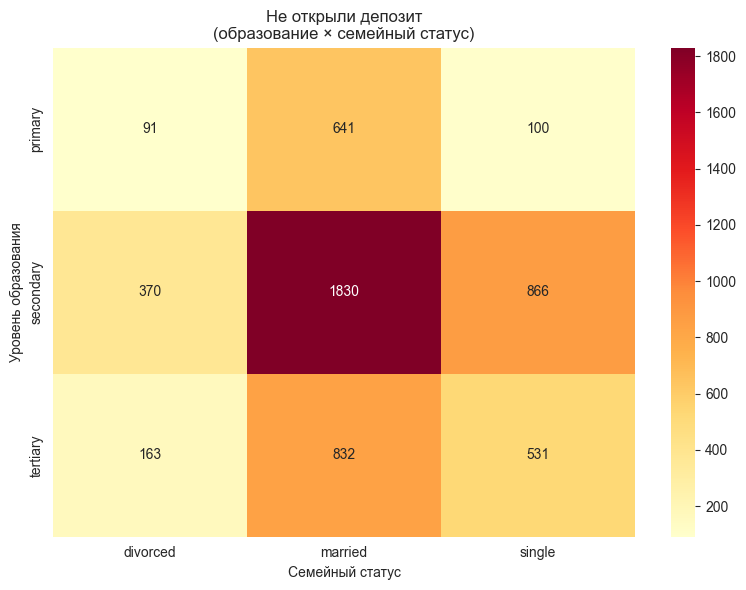

In [204]:
df_yes = df[df['deposit'] == 'yes']
df_no = df[df['deposit'] == 'no']

# Создаем сводные таблицы (education × marital)
pivot_yes = pd.crosstab(df_yes['education'], df_yes['marital'])
pivot_no = pd.crosstab(df_no['education'], df_no['marital'])

# Рисуем тепловую карту для тех, кто открыл депозит
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_yes, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Открыли депозит\n(образование × семейный статус)')
plt.xlabel('Семейный статус')
plt.ylabel('Уровень образования')
plt.tight_layout()
plt.show()

# Рисуем тепловую карту для тех, кто не открыл депозит
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_no, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Не открыли депозит\n(образование × семейный статус)')
plt.xlabel('Семейный статус')
plt.ylabel('Уровень образования')
plt.tight_layout()
plt.show()

## Часть 3: преобразование данных

### Задание 1

In [205]:
label_encoder = LabelEncoder()
df['education'] = label_encoder.fit_transform(df['education'])

In [206]:
df['education'].sum()

11995

In [207]:
df['age_group'] = label_encoder.fit_transform(df['age_group'])

### Задания 2 и 3

In [208]:
df['deposit'] = df['deposit'].replace(['yes', 'no'], [1, 0])

In [209]:
df['deposit'].std()

0.4986712532452124

In [210]:
for feature in ['default', 'housing', 'loan']:
    df[feature] = df[feature].replace(['yes', 'no'], [1, 0])

In [211]:
df['default'].mean() + df['housing'].mean() + df['loan'].mean()

0.6354280059376547

### Задание 4

In [212]:
df = pd.get_dummies(df, columns=['job', 'marital', 'contact', 'month', 'poutcome'])

In [213]:
df.shape

(10105, 46)

### Задания 5 и 6

In [214]:
df.corr(numeric_only=True)

,age,education,default,balance,housing,loan,day,duration,campaign,pdays,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
age,1.000000,-0.191124,-0.009929,0.115164,-0.164196,-0.026357,0.000396,-0.006007,-0.001143,0.006107,...,0.009769,0.024785,-0.119656,0.026875,0.056998,0.036352,0.001994,-0.020942,0.060009,-0.031455
education,-0.191124,1.000000,-0.015692,0.043251,-0.094350,-0.052566,0.008989,-0.016869,-0.012280,0.024123,...,-0.036503,0.052196,-0.104157,0.028704,0.027617,0.030846,0.019845,0.015103,0.070489,-0.069069
default,-0.009929,-0.015692,1.000000,-0.110928,0.009551,0.074786,0.018724,-0.008162,0.033404,-0.037323,...,0.019626,-0.020028,-0.001761,0.000544,-0.023931,-0.016977,-0.025450,-0.017923,-0.041510,0.055032
balance,0.115164,0.043251,-0.110928,1.000000,-0.094919,-0.113089,-0.009987,0.025781,-0.042689,0.045155,...,0.039753,0.043832,-0.098073,0.081861,0.057041,0.047841,0.031040,0.028111,0.073358,-0.085456
housing,-0.164196,-0.094350,0.009551,-0.094919,1.000000,0.072252,-0.022644,0.038492,0.006257,0.064138,...,-0.073133,-0.075948,0.432605,-0.000219,-0.092026,-0.086893,0.085167,0.009830,-0.134477,0.024082
loan,-0.026357,-0.052566,0.074786,-0.113089,0.072252,1.000000,0.019136,0.001476,0.033889,-0.030788,...,-0.014897,-0.041105,0.002778,0.017720,-0.032357,-0.046196,0.007458,-0.019289,-0.082098,0.059235
day,0.000396,0.008989,0.018724,-0.009987,-0.022644,0.019136,1.000000,-0.016695,0.142169,-0.078757,...,-0.182032,-0.044303,-0.014580,0.056471,0.072179,-0.068744,-0.071175,-0.008806,-0.044366,0.085442
duration,-0.006007,-0.016869,-0.008162,0.025781,0.038492,0.001476,-0.016695,1.000000,-0.042576,-0.033053,...,-0.003061,-0.034640,0.007983,-0.015655,-0.012541,-0.012077,-0.039476,-0.009497,-0.025971,0.050571
campaign,-0.001143,-0.012280,0.033404,-0.042689,0.006257,0.033889,0.142169,-0.042576,1.000000,-0.105214,...,0.046763,-0.030574,-0.044348,-0.077307,-0.071519,-0.048672,-0.082282,-0.024854,-0.094260,0.134842
pdays,0.006107,0.024123,-0.037323,0.045155,0.064138,-0.030788,-0.078757,-0.033053,-0.105214,1.000000,...,-0.093551,0.024192,0.028678,-0.007350,0.079833,0.110907,0.608719,0.338049,0.326215,-0.824031


### Задания 7 и 8

In [215]:
X = df.drop(['deposit'], axis=1)
y = df['deposit']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42, test_size=0.33)

In [216]:
X_test.shape

(3335, 45)

In [217]:
y_test.mean()

0.46326836581709147

### Задание 9

In [218]:
selector = SelectKBest(score_func=f_classif, k=15)
X_train_selected = selector.fit_transform(X_train, y_train)

mask = selector.get_support()
selected_columns = X_train.columns[mask].tolist()

X_train_selected = pd.DataFrame(X_train_selected, columns=selected_columns)
X_test_selected = selector.transform(X_test)
X_test_selected = pd.DataFrame(
    X_test_selected,
    columns=selected_columns,
    index=X_test.index
)
X_train_selected.columns

Index(['balance', 'housing', 'duration', 'campaign', 'pdays', 'previous',
       'age_group', 'contact_cellular', 'contact_unknown', 'month_mar',
       'month_may', 'month_oct', 'month_sep', 'poutcome_success',
       'poutcome_unknown'],
      dtype='object')

### Задание 10

In [226]:
scaler = preprocessing.MinMaxScaler()
scaler.fit(X_train_selected)

X_train_scaled = pd.DataFrame(scaler.transform(X_train_selected))
X_test_scaled = pd.DataFrame(scaler.transform(X_test_selected))

In [233]:
X_test_scaled.iloc[:, 0].mean()

0.46823674223097866

# Часть 4: Решение задачи классификации: логистическая регрессия и решающие деревья

### Задание 1

In [235]:
log_reg = linear_model.LogisticRegression(solver='sag', random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
metrics.accuracy_score(y_test, y_pred)

0.8047976011994002

### Задания 2,3,4

In [245]:
tree_model = tree.DecisionTreeClassifier(random_state=42, criterion='entropy', max_depth=7)
tree_model.fit(X_train_scaled, y_train)

y_pred = tree_model.predict(X_test_scaled)
print(metrics.accuracy_score(y_test, y_pred))

0.8185907046476761


<Axes: xlabel='depth', ylabel='ac'>

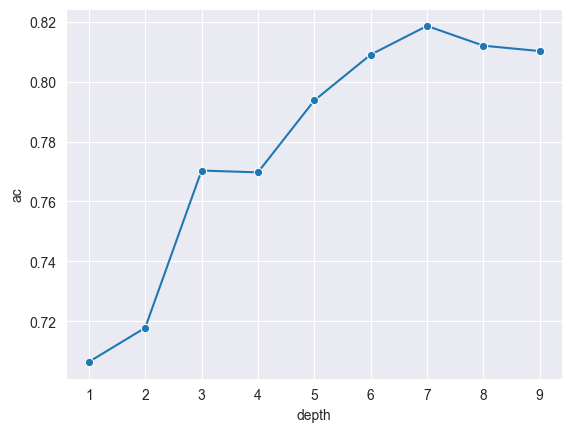

In [244]:
res = {"ac": [], 'depth': []}
max_depths = np.arange(1, 10, 1)

for max_depth in max_depths:
    tree_model = tree.DecisionTreeClassifier(
        random_state=42,
        criterion='entropy',
        max_depth=max_depth
    )
    tree_model.fit(X_train_scaled, y_train)

    y_pred = tree_model.predict(X_test_scaled)
    res['ac'].append(metrics.accuracy_score(y_test, y_pred))
    res['depth'].append(max_depth)

res_df = pd.DataFrame(res)

sns.lineplot(data=res_df, x="depth", y="ac", marker="o")

In [249]:
grid_param = {
    'min_samples_split': [2, 5, 7, 10],
    'max_depth': [3, 5, 7],
}
grid = GridSearchCV(
    estimator=tree.DecisionTreeClassifier(
        random_state=42,
        criterion='entropy'
    ),
    param_grid=grid_param,
    scoring='f1'
)
grid.fit(X_train_scaled, y_train)
grid.best_params_

{'max_depth': 7, 'min_samples_split': 10}

In [252]:
tree_model = tree.DecisionTreeClassifier(
    random_state=42,
    criterion='entropy',
    max_depth=7,
    min_samples_split=10
)
tree_model.fit(X_train_scaled, y_train)

y_pred = tree_model.predict(X_test_scaled)
print(metrics.f1_score(y_test, y_pred))

0.805484693877551


# Часть 5: Решение задачи классификации: ансамбли моделей и построение прогноза

### Задание 1

In [253]:
rand_forest = ensemble.RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    min_samples_leaf=5,
    max_depth=10,
    random_state=42
)
rand_forest.fit(X_train_scaled, y_train)
y_pred = rand_forest.predict(X_test_scaled)

print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.82      0.84      1790
           1       0.80      0.83      0.82      1545

    accuracy                           0.83      3335
   macro avg       0.83      0.83      0.83      3335
weighted avg       0.83      0.83      0.83      3335



### Задания 2 и 3

In [254]:
grad_boost = ensemble.GradientBoostingClassifier(
    learning_rate=0.05,
    n_estimators=300,
    min_samples_leaf=5,
    max_depth=5,
    random_state=42
)
grad_boost.fit(X_train_scaled, y_train)
y_pred = grad_boost.predict(X_test_scaled)

print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.82      0.84      1790
           1       0.80      0.83      0.82      1545

    accuracy                           0.83      3335
   macro avg       0.83      0.83      0.83      3335
weighted avg       0.83      0.83      0.83      3335



### Задание 4

In [255]:
base_estimators = [
    ('rf', ensemble.RandomForestClassifier(
        n_estimators=100,
        criterion='gini',
        min_samples_leaf=5,
        max_depth=10,
        random_state=42
    )),
    ('gb', ensemble.GradientBoostingClassifier(
        learning_rate=0.05,
        n_estimators=300,
        min_samples_leaf=5,
        max_depth=5,
        random_state=42
    ))
]

# 2. Определяем мета-модель
meta_model = linear_model.LogisticRegression(solver='sag', random_state=42, max_iter=1000)

# 3. Собираем стекинг-классификатор
stack = ensemble.StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_model,
    n_jobs=-1
)
stack.fit(X_train_scaled, y_train)

y_pred = stack.predict(X_test_scaled)

Connection closed unexpectedly!


In [256]:
metrics.precision_score(y_test, y_pred)

0.8051865907653384

### Задание 5

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'balance'),
  Text(1, 0, 'housing'),
  Text(2, 0, 'duration'),
  Text(3, 0, 'campaign'),
  Text(4, 0, 'pdays'),
  Text(5, 0, 'previous'),
  Text(6, 0, 'age_group'),
  Text(7, 0, 'contact_cellular'),
  Text(8, 0, 'contact_unknown'),
  Text(9, 0, 'month_mar'),
  Text(10, 0, 'month_may'),
  Text(11, 0, 'month_oct'),
  Text(12, 0, 'month_sep'),
  Text(13, 0, 'poutcome_success'),
  Text(14, 0, 'poutcome_unknown')])

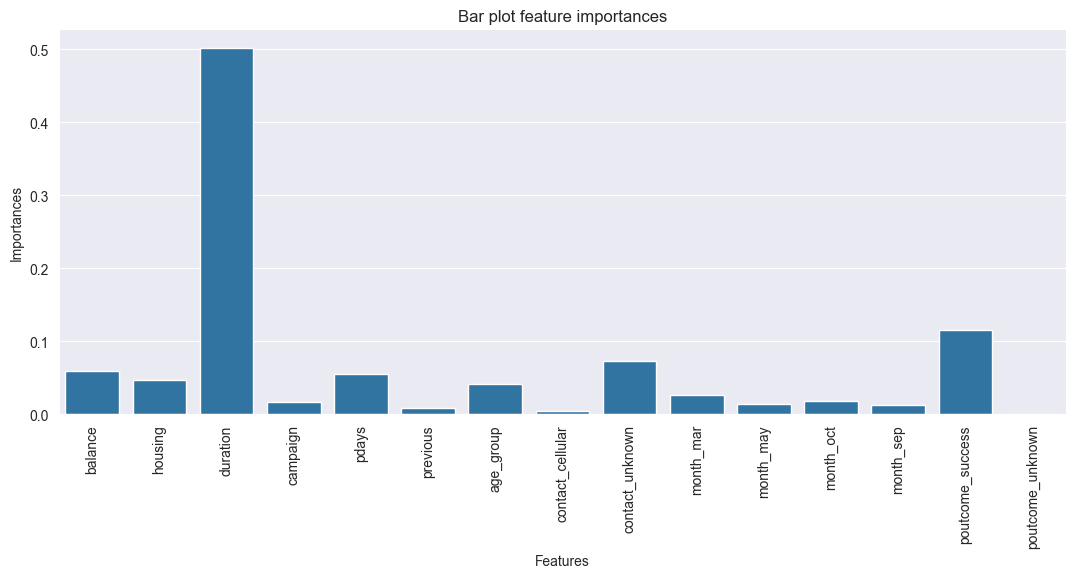

In [261]:
fig, ax = plt.subplots(figsize=(13, 5))  #фигура + координатная плоскость
feature = X_test_selected.columns  #признаки
feature_importances = grad_boost.feature_importances_  #важность признаков
#Строим столбчатую диаграмму
sns.barplot(x=feature, y=feature_importances, ax=ax)
#Добавляем подпись графику, осям абсцисс и ординат
ax.set_title('Bar plot feature importances')
ax.set_xlabel('Features')
ax.set_ylabel('Importances')
plt.xticks(rotation=90)

### Задания 6,7,8

In [266]:
def optuna_rf(trial):
    n_estimators = trial.suggest_int('n_estimators', 100, 200, 1)
    max_depth = trial.suggest_int('max_depth', 10, 30, 1)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 2, 10, 1)

    model = ensemble.RandomForestClassifier(n_estimators=n_estimators,
                                            max_depth=max_depth,
                                            min_samples_leaf=min_samples_leaf,
                                            random_state=42)
    # обучаем модель
    model.fit(X_train_scaled, y_train)
    score = metrics.f1_score(y_test, model.predict(X_test_scaled))
    return score

In [267]:
study = optuna.create_study(study_name="RandomForestClassifier", direction="maximize")
# ищем лучшую комбинацию гиперпараметров n_trials раз
study.optimize(optuna_rf, n_trials=20)
# выводим результаты на обучающей выборке
print("Наилучшие значения гиперпараметров {}".format(study.best_params))
print("f1_score на обучающем наборе: {:.2f}".format(study.best_value))

[I 2025-07-19 12:22:49,705] A new study created in memory with name: RandomForestClassifier
[I 2025-07-19 12:22:50,305] Trial 0 finished with value: 0.8151898734177215 and parameters: {'n_estimators': 197, 'max_depth': 25, 'min_samples_leaf': 8}. Best is trial 0 with value: 0.8151898734177215.
[I 2025-07-19 12:22:50,888] Trial 1 finished with value: 0.8155646947168618 and parameters: {'n_estimators': 195, 'max_depth': 26, 'min_samples_leaf': 8}. Best is trial 1 with value: 0.8155646947168618.
[I 2025-07-19 12:22:51,431] Trial 2 finished with value: 0.8192392329456146 and parameters: {'n_estimators': 177, 'max_depth': 23, 'min_samples_leaf': 6}. Best is trial 2 with value: 0.8192392329456146.
[I 2025-07-19 12:22:51,905] Trial 3 finished with value: 0.8152380952380952 and parameters: {'n_estimators': 171, 'max_depth': 10, 'min_samples_leaf': 5}. Best is trial 2 with value: 0.8192392329456146.
[I 2025-07-19 12:22:52,274] Trial 4 finished with value: 0.8141086749285034 and parameters: {'n_

Наилучшие значения гиперпараметров {'n_estimators': 112, 'max_depth': 14, 'min_samples_leaf': 2}
f1_score на обучающем наборе: 0.82
